In [1]:
%pip install pandas matplotlib scikit-learn


[notice] A new release of pip is available: 24.3.1 -> 26.1
[notice] To update, run: /Users/antoinelaborde/workspace/eni/mlops/.venv/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

In [4]:
file_path = "../data/raw.txt"
df = pd.read_csv(file_path, delimiter=";", index_col=0, decimal=",")
df.index.name = "timestamp"


In [5]:
df_long = df.reset_index().melt(
    id_vars="timestamp",
    var_name="individual",
    value_name="consumption"
)

In [6]:
df_long["timestamp"] = pd.to_datetime(df_long["timestamp"])
df_long["year_month"] = df_long["timestamp"].dt.to_period("M")

In [8]:
# Aggregate consumption by individual and year_month
df_agg = (
    df_long
    .groupby(["individual", "year_month"])["consumption"]
    .sum()
    .reset_index()
)

In [9]:
# Pivot the DataFrame to get the final shape: individual x year_month
df_final = df_agg.pivot(
    index="individual",
    columns="year_month",
    values="consumption"
)

In [10]:
# Filter out individuals with too high overall consumption or to many zeros
total_sum = df_final.sum(axis=1)
nbr_to_zeros = df_final[df_final == 0].count(axis=1)

In [11]:
total_sum.describe()

count    3.700000e+02
mean     7.412982e+07
std      3.388795e+08
min      1.147376e+05
25%      5.876048e+06
50%      1.496452e+07
75%      4.235279e+07
max      5.274746e+09
dtype: float64

In [12]:
nbr_to_zeros.describe()

count    370.000000
mean       9.281081
std       10.236071
min        0.000000
25%        0.000000
50%       12.000000
75%       12.000000
max       42.000000
dtype: float64

In [13]:
filtered_individuals = df_final[((nbr_to_zeros == 0) & (total_sum <= 4.2e7) & (5.9e6 <= total_sum))].index

<Axes: xlabel='year_month'>

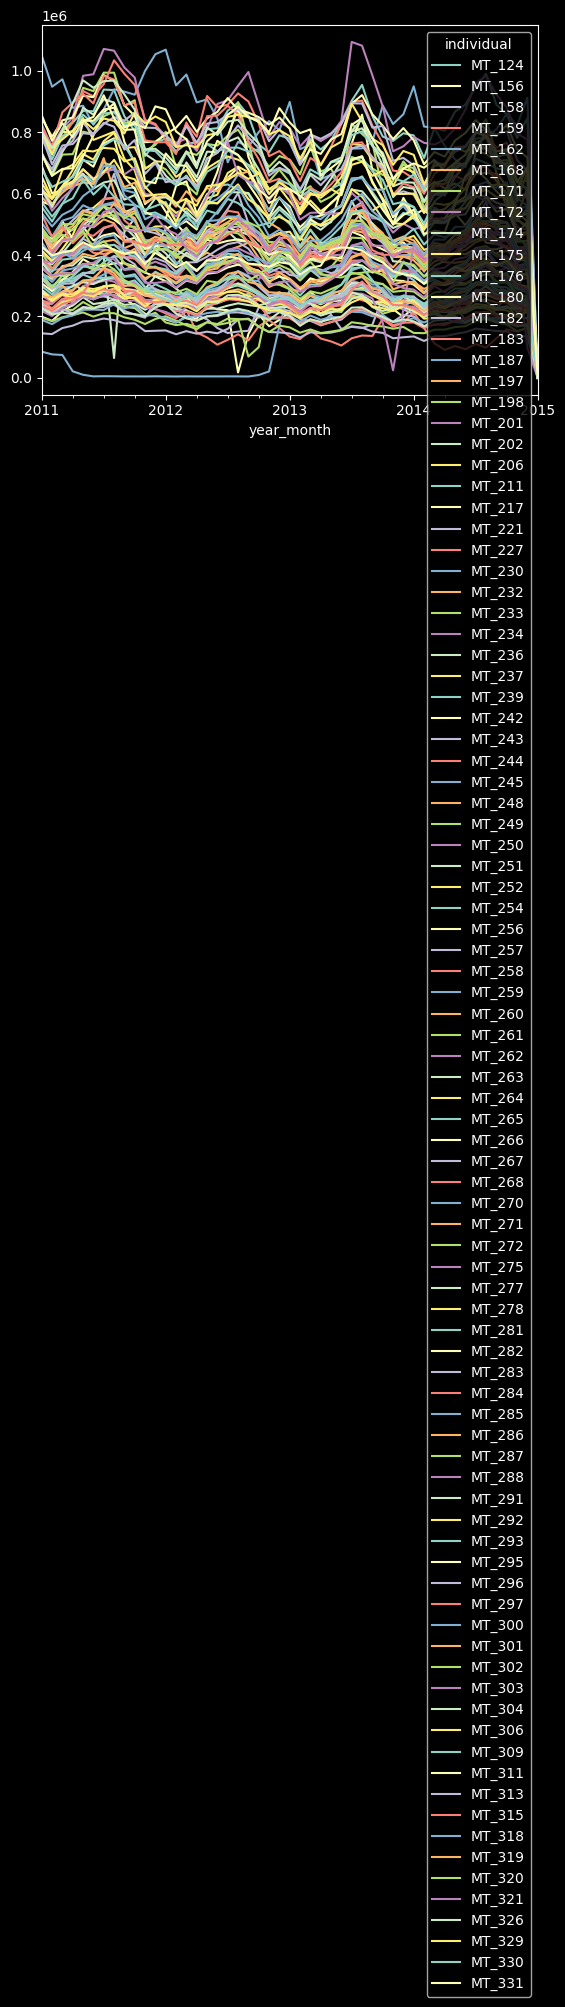

In [15]:
df_final[df_final.index.isin(filtered_individuals)].T.plot()